# (B) 1.

**Import your package in the documentation notebook**

In [1]:
# Import package here

# (B) 2.

**Describe your generative model**

We will model the observed data as an image of flouresence from a single NV center measured at a fixed microwave frequency $f_{MW}$. Each data point is recorded at a pixel in a 2D array, such that our data is:
$$
D = \{y_{ij}\}
$$
where $y_{ij}$ is the measured flourescene rate in kCounts/s at pixel $(i, j)$. The goal, from this data, is to infer the parameters of a magnetic dipole from this image. 

For the purpose of this preliminary model, we will only consider the following parameters: 
- single magnetic dipole
- known NV axis $\mathbf{\hat{n}}$
- Lorentzian fluorescence dip as a function of detuning
- constant background floresence
- independent Gaussian pixel noise

**Parameters:** For the full parameter vector, consider:

$$
\theta = \left(x_d, y_d, z_d, m_x, m_y, m_z, \beta_0, C, \Gamma, \delta_0, \sigma\right).
$$

Where:

- $(x_d, y_d, z_d)$: dipole position
- $(m_x, m_y, m_z)$: dipole moment components
- $\beta_0, \beta_x, \beta_y$: background offset and linear gradients
- $C$: fluorescence dip contrast
- $\Gamma$: resonance linewidth parameter
- $\delta_0$: global detuning offset
- $\sigma$: standard deviation of the pixel noise

What we will have as input from the image data is the pixel coordinate, i.e. the relative position of the NV center with respect to the NV center. For the defined coordinates $(i, j)$, the full scan coordiante is then
$$
\mathbf{r_{ij}} = (x_{ij}, y_{ij}, z_{NV})
$$
Where $z_{NV}$ is the height of the imaging plane. 

**Dipole B-Field**: We model the magnet as a simple point dipole located at 
$$
\mathbf{r_d} = (x_d, y_d, z_d)
$$
with dipole moment

$$
\mathbf{m} = (m_x, m_y, m_z)
$$
This allows us to define
$$
\mathbf R_{ij} = \mathbf r_{ij} - \mathbf r_d,
\qquad
R_{ij} = \|\mathbf R_{ij}\|,
\qquad
\hat{\mathbf R}_{ij} = \frac{\mathbf R_{ij}}{R_{ij}}.
$$
As the parameter for distance and direction of the displacement of the NV from the dipole. Then, we know that for any given pixel $(i, j)$, the dipole field at that pixel is: 
$$
\mathbf B_{ij}(\theta) = \frac{\mu_0}{4\pi R_{ij}^3} \left[3(\mathbf m \cdot \hat{\mathbf R}_{ij}) \hat{\mathbf R}_{ij} - \mathbf m \right].
$$
Finally, if we assume that the NV orientation is known, then the relevant field component which will impact the spin transition of the NV center is: 
$$
B_{\parallel,ij}(\theta) = \mathbf B_{ij}(\theta) \cdot \hat{\mathbf n}.
$$

**Resonance model:** We are sending in a known, fixed microwave freqeuncy to the system. What we then care about is the detuning between this microwave field and where the NV resonance is. This can be modeled as: 
$$
\Delta_{ij}(\theta) = \delta_0 - \gamma B_{\parallel,ij}(\theta),
$$

where $\gamma$ is the known NV gyromagnetic factor and $\delta_0$ is some global term that encompasses uncertainty in the resonance position. 

The dip itself then can be modeled using a Lorentzian line shape. There will be some global background florecense, as well as a contrast parameter $C$ which is intrinsic to the NV center, and will be known. Typically, $C$ is in the range of 25%. Let us then define our signal as: 
$$
\mu_{ij}(\theta) = \beta_0\left[1 - C \frac{1}{1 + \left( \frac{\Delta_{ij}(\theta)}{\Gamma} \right)^2} \right]
$$
Which means the flourecence will be lowest when $\Delta_{ij}$ is appraoching zero, which will produce the dark line that we see on the contour!

**Likelyhood:** Now for the likelyhood, we model each observed pixel as independent gaussian random variables:
$$
y_{ij} \mid \theta \sim \mathcal N\!\left(\mu_{ij}(\theta), \sigma^2\right).
$$
such that the likelyhood for the entire image is
$$
p(D \mid \theta) = \prod_{i,j} \mathcal{N} \!\left(y_{ij} \mid \mu_{ij}(\theta), \sigma^2\right).
$$
Which, for right now, we aknowledge is an aproximation for the true counting statistics. But because each pixel is an averaged flouresence, the noise should be approximately gaussian. 

**Priors:** Now, in order to complete our model, we need to assign priors to each of the unknown parameters. 

For the dipole position, we say that the dipole may appear anywhere within the region of the image with equal probability: 
$$
x_d \sim \mathrm{Uniform}(x_{\min}, x_{\max}),
\qquad
y_d \sim \mathrm{Uniform}(y_{\min}, y_{\max}),
\qquad
z_d \sim \mathrm{Uniform}(z_{\min}, z_{\max}).
$$

For the dipole itself, it is typically magnetized experimentally by applying an external field approximately along the z-axis. Thus, we should use a prior that favors a dipole moment that points roughly along the z-axis, but allows for imperfect alignment in x and y: 
$$
m_x \sim \mathcal{N}(0, s_\perp^2), 
\qquad
m_y \sim \mathcal{N}(0, s_\perp^2), 
\qquad
m_z \sim \mathcal{N}(m_{z,0}, s_z^2)
$$

For the background, the baseline intensity has a rough expected scale, which can be determined emperically from the images or prior scans with the NV center. For this reason, we center the prior at this value with a normal distribution:
$$
\beta_0 \sim \mathcal{N}(\bar{y}, s_{\beta_0}^2)
$$

For the remaining parameters dip contrast, linewidth, and noise standard deviation, we know we need to enforce positivity when we have a generally known scale for the parameter. For this case, we use exponential parameters: 
$$
\Gamma \sim \text{Exponential}(\lambda_\Gamma), 
\qquad
\sigma \sim \text{Exponential}(\lambda_\sigma), 
$$

As well as the contrast $C$ for the system, which we know is a value bounded by $[0, 1]$. With this information we use a Beta prior:
$$
C \sim \text{Beta}(\alpha_C, \beta_C)
$$

Finally, we have some detuning offset which has a natural reference point of zero, but we shoudl allow for deviations on either side of zero, which is a natural choice for a normal prior:
$$
\delta_0 \sim \mathcal{N}(0, s_\delta^2)
$$

Now we may finally think about the joint distribution, which may be written as: 
$$
p(\theta, D) = p(\theta)\prod_{i,j} p(y_{ij}\mid \theta)
$$

with

$$
p(\theta) =
p(x_d)p(y_d)p(z_d)p(m_x)p(m_y)p(m_z)
p(\beta_0)p(C)p(\Gamma)p(\delta_0)p(\sigma),
$$

and 

$$
p(y_{ij}\mid \theta) = \mathcal N\!\left(y_{ij}\mid \mu_{ij}(\theta), \sigma^2\right)
$$

So that the posterior distribution is:

$$
p(\theta \mid D)
\propto
p(D\mid \theta)\,p(\theta).
$$

Right now, we are accounting for the noise with a standard deviation $\sigma$ which absorbs photon counting, detector noise, fluorescence fluctuations, etc. 

# (B) 3.

**Simulate some data using your generative model**

For the simulation, we absorb constants for ease of coding and display. There should technically be a $\mu_0/(4\pi)$ in the dipole, and the gyromagnetic ratio for an electron should be used when determining $\Delta$. This will be incorporated when we implenent the model for real, right now I mostly care about the shape. 

I'm aiming to recreate data as seen in the image here, something along these lines:

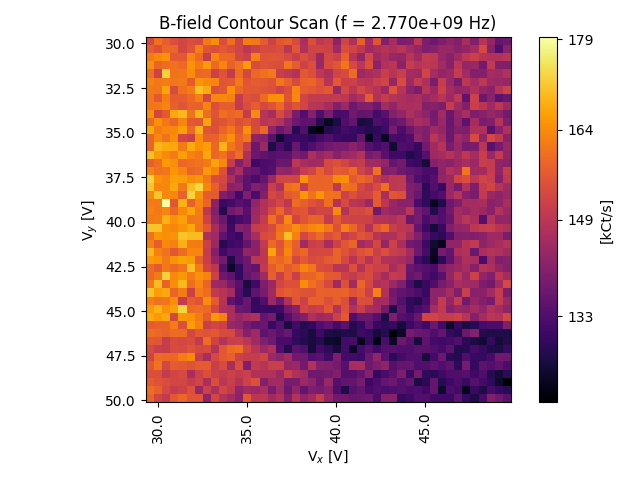

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ---------------------------------------
# Define some set parameters for the scan
# ---------------------------------------

n_pix = 45
vx = np.linspace(30.0, 50.0, n_pix)
vy = np.linspace(30.0, 50.0, n_pix)

VX, VY = np.meshgrid(vx, vy)

# ---------------------------------------
# We have a known volt -> um conversion
# ---------------------------------------
volt_to_um = 0.02
X = VX * volt_to_um
Y = VY * volt_to_um

# ---------------------------------------
# Our third dimension will be the image data
# ---------------------------------------
Z = np.zeros_like(X)

In [3]:
def dipole_field(X, Y, Z, x_d, y_d, z_d, m_vec):
    """
    Will compute the magnetic field from a dipole
    on a 2D grid

    Input
    -----
    X, Y, Z: 2D arrays representing the observation coordinates
    x_d, y_d, z_d: float: dipole position
    m_vec : array of length 3: dipole moment vector

    Returns
    -------
    Bx, By, Bz : 2D arrays, magnetic field components
    
    """
    mx, my, mz = m_vec

    Rx = X - x_d
    Ry = Y - y_d
    Rz = Z - z_d

    R2 = Rx**2 + Ry**2 + Rz**2
    R = np.sqrt(R2)

    # include a safety cutoff value to top R^3, R^5 terms from blowing up
    lim = 1e-12
    R = np.maximum(R, lim)

    m_dot_R = mx*Rx + my*Ry + mz*Rz

    Bx = 3.0 * m_dot_R * Rx / R**5 - mx / R**3
    By = 3.0 * m_dot_R * Ry / R**5 - my / R**3
    Bz = 3.0 * m_dot_R * Rz / R**5 - mz / R**3

    return Bx, By, Bz

In [4]:
def mean_fluorescence(
    X, Y, Z, 
    x_d, y_d, z_d, 
    m_vec, 
    n_vec, 
    beta0, 
    C, 
    Gamma, 
    delta0
):
    """
    Computes the fluorescence for the image (noiseless)

    inputs
    ------
    UPDATE

    Returns
    -------
    UPDATE
    """

    Bx, By, Bz = dipole_field(X, Y, Z, x_d, y_d, z_d, m_vec)

    nx, ny, nz = n_vec
    B_par = nx*Bx + ny*By + nz*Bz

    Delta = delta0 - B_par

    lorentzian = 1.0 / (1.0 + (Delta/Gamma)**2)
    mu = beta0 * (1.0 - C*lorentzian)

    return mu, B_par, Delta

In [5]:
# ---------------------------------------
# Choose the TRUE parameter values
# ---------------------------------------

# dipole position, arbitrary position
x_d_true = 0.80
y_d_true = 0.81
z_d_true = -0.078

# Dipole moment (mostly z with small tilt)
m_vec_true = np.array([0.15, -0.08, 1.00])

# Our known NV axis
n_vec_true = np.array([0.0, 0.0, 1.00])

# Global Background
beta0_true = 145.0 #kc/s

# Lorentzian dip params
C_true = 0.30
Gamma_true = 40.0
delta0_true = 28.0

# Noise level?
sigma_true = 2.5 #kc/s

In [6]:
# ---------------------------------------------
# Simulate the noiseless image from true values
# ---------------------------------------------

mu_true, Bpar_true, Delta_true = mean_fluorescence(
    X, Y, Z, 
    x_d_true, y_d_true, z_d_true,
    m_vec_true,
    n_vec_true, 
    beta0_true,
    C_true, 
    Gamma_true,
    delta0_true
)

# And now draw noisy observations
rng = np.random.default_rng(1)
y_sim = rng.normal(loc=mu_true, scale=sigma_true, size=mu_true.shape)

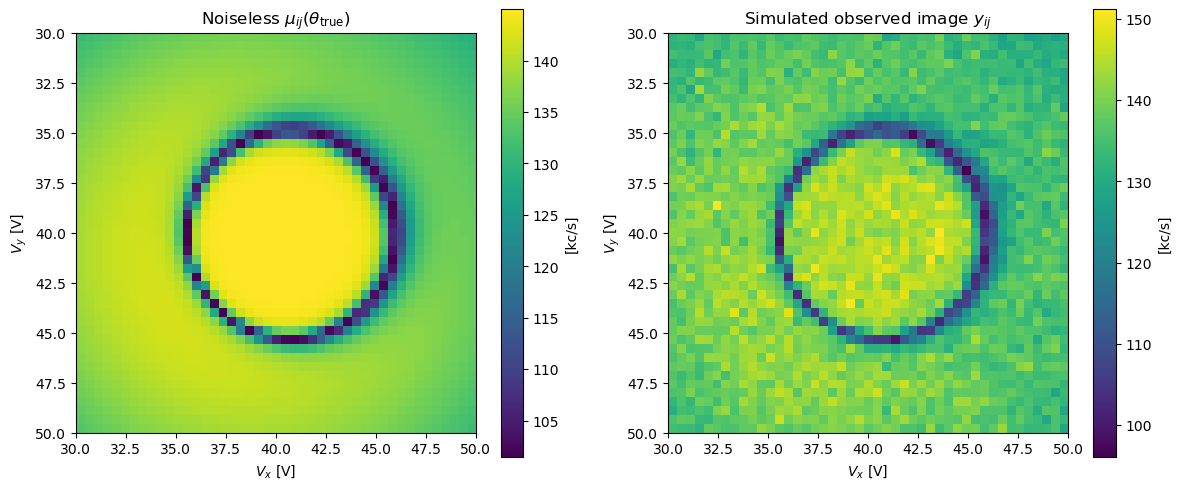

In [7]:
# -----------------------
# Plot our simulated data
# -----------------------

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

im0 = axes[0].imshow(mu_true,extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[0].set_title("Noiseless $\\mu_{ij}(\\theta_{\\rm true})$")
axes[0].set_xlabel("$V_x$ [V]")
axes[0].set_ylabel("$V_y$ [V]")
plt.colorbar(im0, ax=axes[0], label="[kc/s]")

im1 = axes[1].imshow(y_sim, extent=[vx.min(), vx.max(), vy.max(), vy.min()])
axes[1].set_title("Simulated observed image $y_{ij}$")
axes[1].set_xlabel("$V_x$ [V]")
axes[1].set_ylabel("$V_y$ [V]")
plt.colorbar(im1, ax=axes[1], label="[kc/s]")

plt.tight_layout()
plt.show()

Which looks like a pretty close replica of the original image to me!

# (B) 4.

**Infer parameters from your simulated data**

In [8]:
import pymc as pm
import pytensor.tensor as pt
import arviz as az

Lets make our functions pytensor compatible so we can use them with PyMC:

In [9]:
def dipole_field_pt(X, Y, Z, x_d, y_d, z_d, m_x, m_y, m_z):
    Rx = X - x_d
    Ry = Y - y_d
    Rz = Z - z_d

    R2 = Rx**2 + Ry**2 + Rz**2
    R2 = pt.maximum(R2, 1e-12)
    R = pt.sqrt(R2)

    m_dot_R = m_x * Rx + m_y * Ry + m_z * Rz

    Bx = 3.0 * m_dot_R * Rx / R**5 - m_x / R**3
    By = 3.0 * m_dot_R * Ry / R**5 - m_y / R**3
    Bz = 3.0 * m_dot_R * Rz / R**5 - m_z / R**3

    return Bx, By, Bz

In [10]:
def mean_fluorescence_pt(X, Y, Z, x_d, y_d, z_d,
                         m_x, m_y, m_z,
                         beta0, C, Gamma, delta0, n_vec):
    
    Bx, By, Bz = dipole_field_pt(X, Y, Z, x_d, y_d, z_d, m_x, m_y, m_z)

    nx, ny, nz = n_vec
    B_par = nx * Bx + ny * By + nz * Bz

    Delta = delta0 - B_par
    L = 1.0 / (1.0 + (Delta / Gamma)**2)
    mu = beta0 * (1.0 - C * L)

    return mu, B_par, Delta

Initializing NUTS using adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [d, C, beta0, x_d, y_d, delta0, Gamma]


Output()

Sampling 4 chains for 3_000 tune and 3_000 draw iterations (12_000 + 12_000 draws total) took 16 seconds.


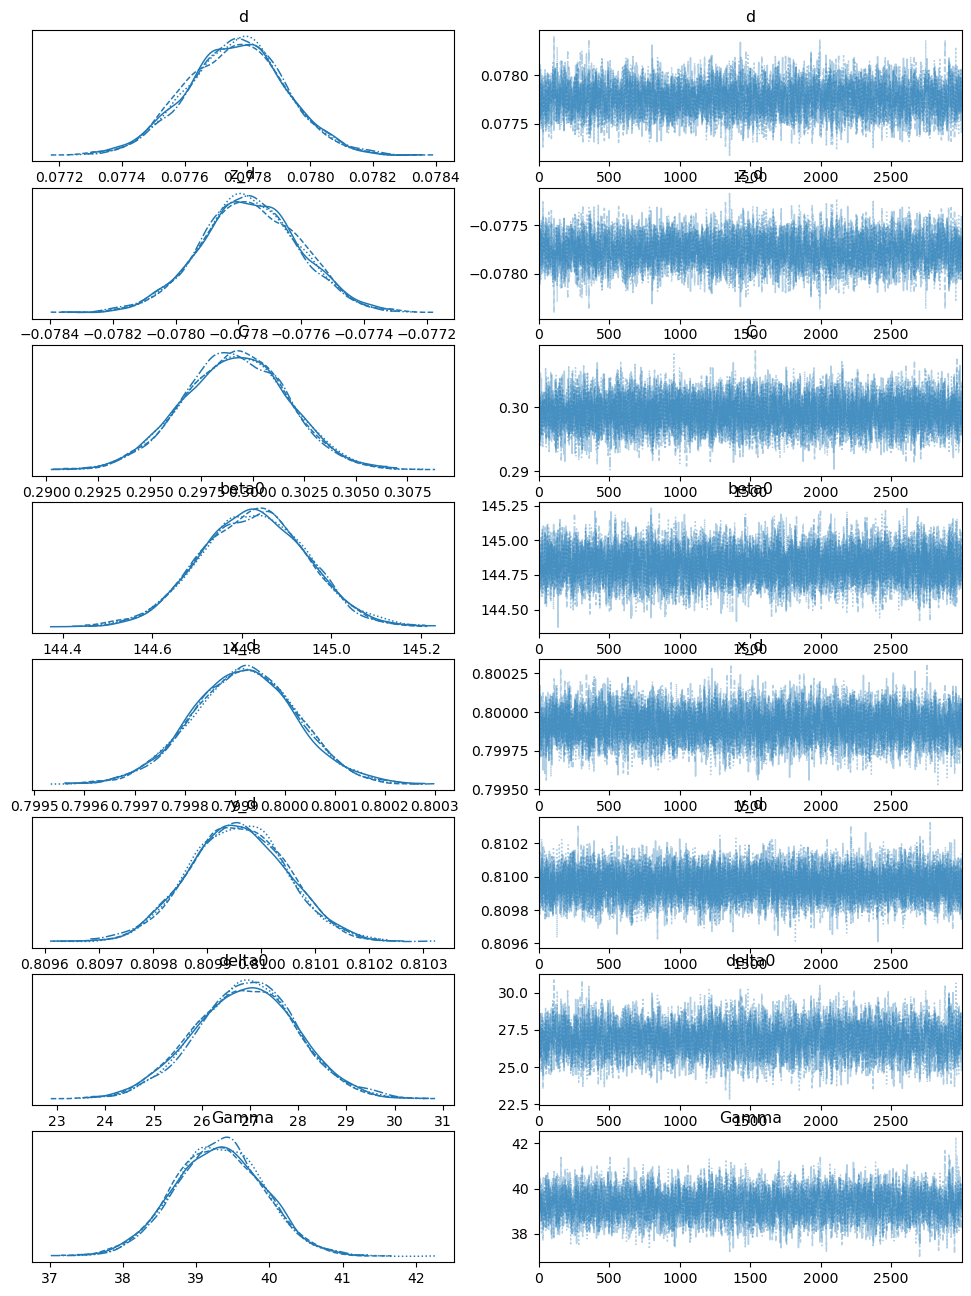

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
d,0.078,0.000,0.077,0.078,0.000,0.000,4068.0,5277.0,1.0
z_d,-0.078,0.000,-0.078,-0.077,0.000,0.000,4068.0,5277.0,1.0
C,0.299,0.002,0.295,0.304,0.000,0.000,8593.0,8270.0,1.0
beta0,144.826,0.118,144.603,145.045,0.001,0.001,7199.0,8065.0,1.0
x_d,0.800,0.000,0.800,0.800,0.000,0.000,6135.0,6987.0,1.0
y_d,0.810,0.000,0.810,0.810,0.000,0.000,8384.0,8197.0,1.0
delta0,26.916,1.055,24.831,28.815,0.017,0.011,3991.0,4735.0,1.0
Gamma,39.308,0.609,38.183,40.458,0.009,0.006,4147.0,5961.0,1.0


In [17]:
with pm.Model() as nv_model:

    X_shared = pm.Data("X_shared", X.astype("float64"))
    Y_shared = pm.Data("Y_shared", Y.astype("float64"))
    Z_shared = pm.Data("Z_shared", Z.astype("float64"))
    y_shared = pm.Data("y_shared", y_sim.astype("float64"))

    # Giving the model something easy to work with here...
    d = pm.Normal("d", mu=0.078, sigma=0.02)
    z_d = pm.Deterministic("z_d", -d)

    # From 0-1, average of 0.3, weighted towards lower values
    C = pm.Beta("C", alpha=2.0, beta=5.0)

    # Take average count from data set as guess
    beta0 = pm.Normal("beta0", mu=float(np.mean(y_sim)), sigma=10.0)

    # Uniform across um range
    x_d = pm.Uniform("x_d", lower=0.55, upper=1.05)
    y_d = pm.Uniform("y_d", lower=0.55, upper=1.05)

    # limited by some instrument or NV property?
    delta0 = pm.Uniform("delta0", lower=-40.0, upper=40.0)

    # also trying to make this distribution as easy as possible right now
    Gamma = pm.Exponential("Gamma", lam=1/40.0)

    # Adding values of m_x, m_y, m_z breaks HMC model
    # m_x = pm.Normal("m_x", mu=0.0, sigma=0.5)

    mu_model, B_par, Delta = mean_fluorescence_pt(
        X_shared, Y_shared, Z_shared,
        x_d, y_d, z_d,
        m_vec_true[0], m_vec_true[1], m_vec_true[2],
        beta0, C, Gamma, delta0,
        n_vec_true
    )

    y_like = pm.Normal("y_like", mu=mu_model, sigma=sigma_true, observed=y_shared)

with nv_model:
    nv_samples = pm.sample(
        tune=3000,
        draws=3000,
        chains=4,
        init="adapt_diag",
        target_accept=0.9,
        random_seed=11,
        return_inferencedata=True
    )

az.plot_trace(nv_samples, var_names=["d", "z_d", "C", "beta0", "x_d", "y_d", "delta0", "Gamma"])
plt.show()

az.summary(nv_samples, var_names=["d", "z_d", "C", "beta0", "x_d", "y_d", "delta0", "Gamma"])

array([[<Axes: ylabel='z_d'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='C'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='beta0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='x_d'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='y_d'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: ylabel='delta0'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >],
       [<Axes: xlabel='z_d', ylabel='Gamma'>, <Axes: xlabel='C'>,
        <Axes: xlabel='beta0'>, <Axes: xlabel='x_d'>,
        <Axes: xlabel='y_d'>, <Axes: xlabel='delta0'>,
        <Axes: xlabel='Gamma'>]], dtype=object)

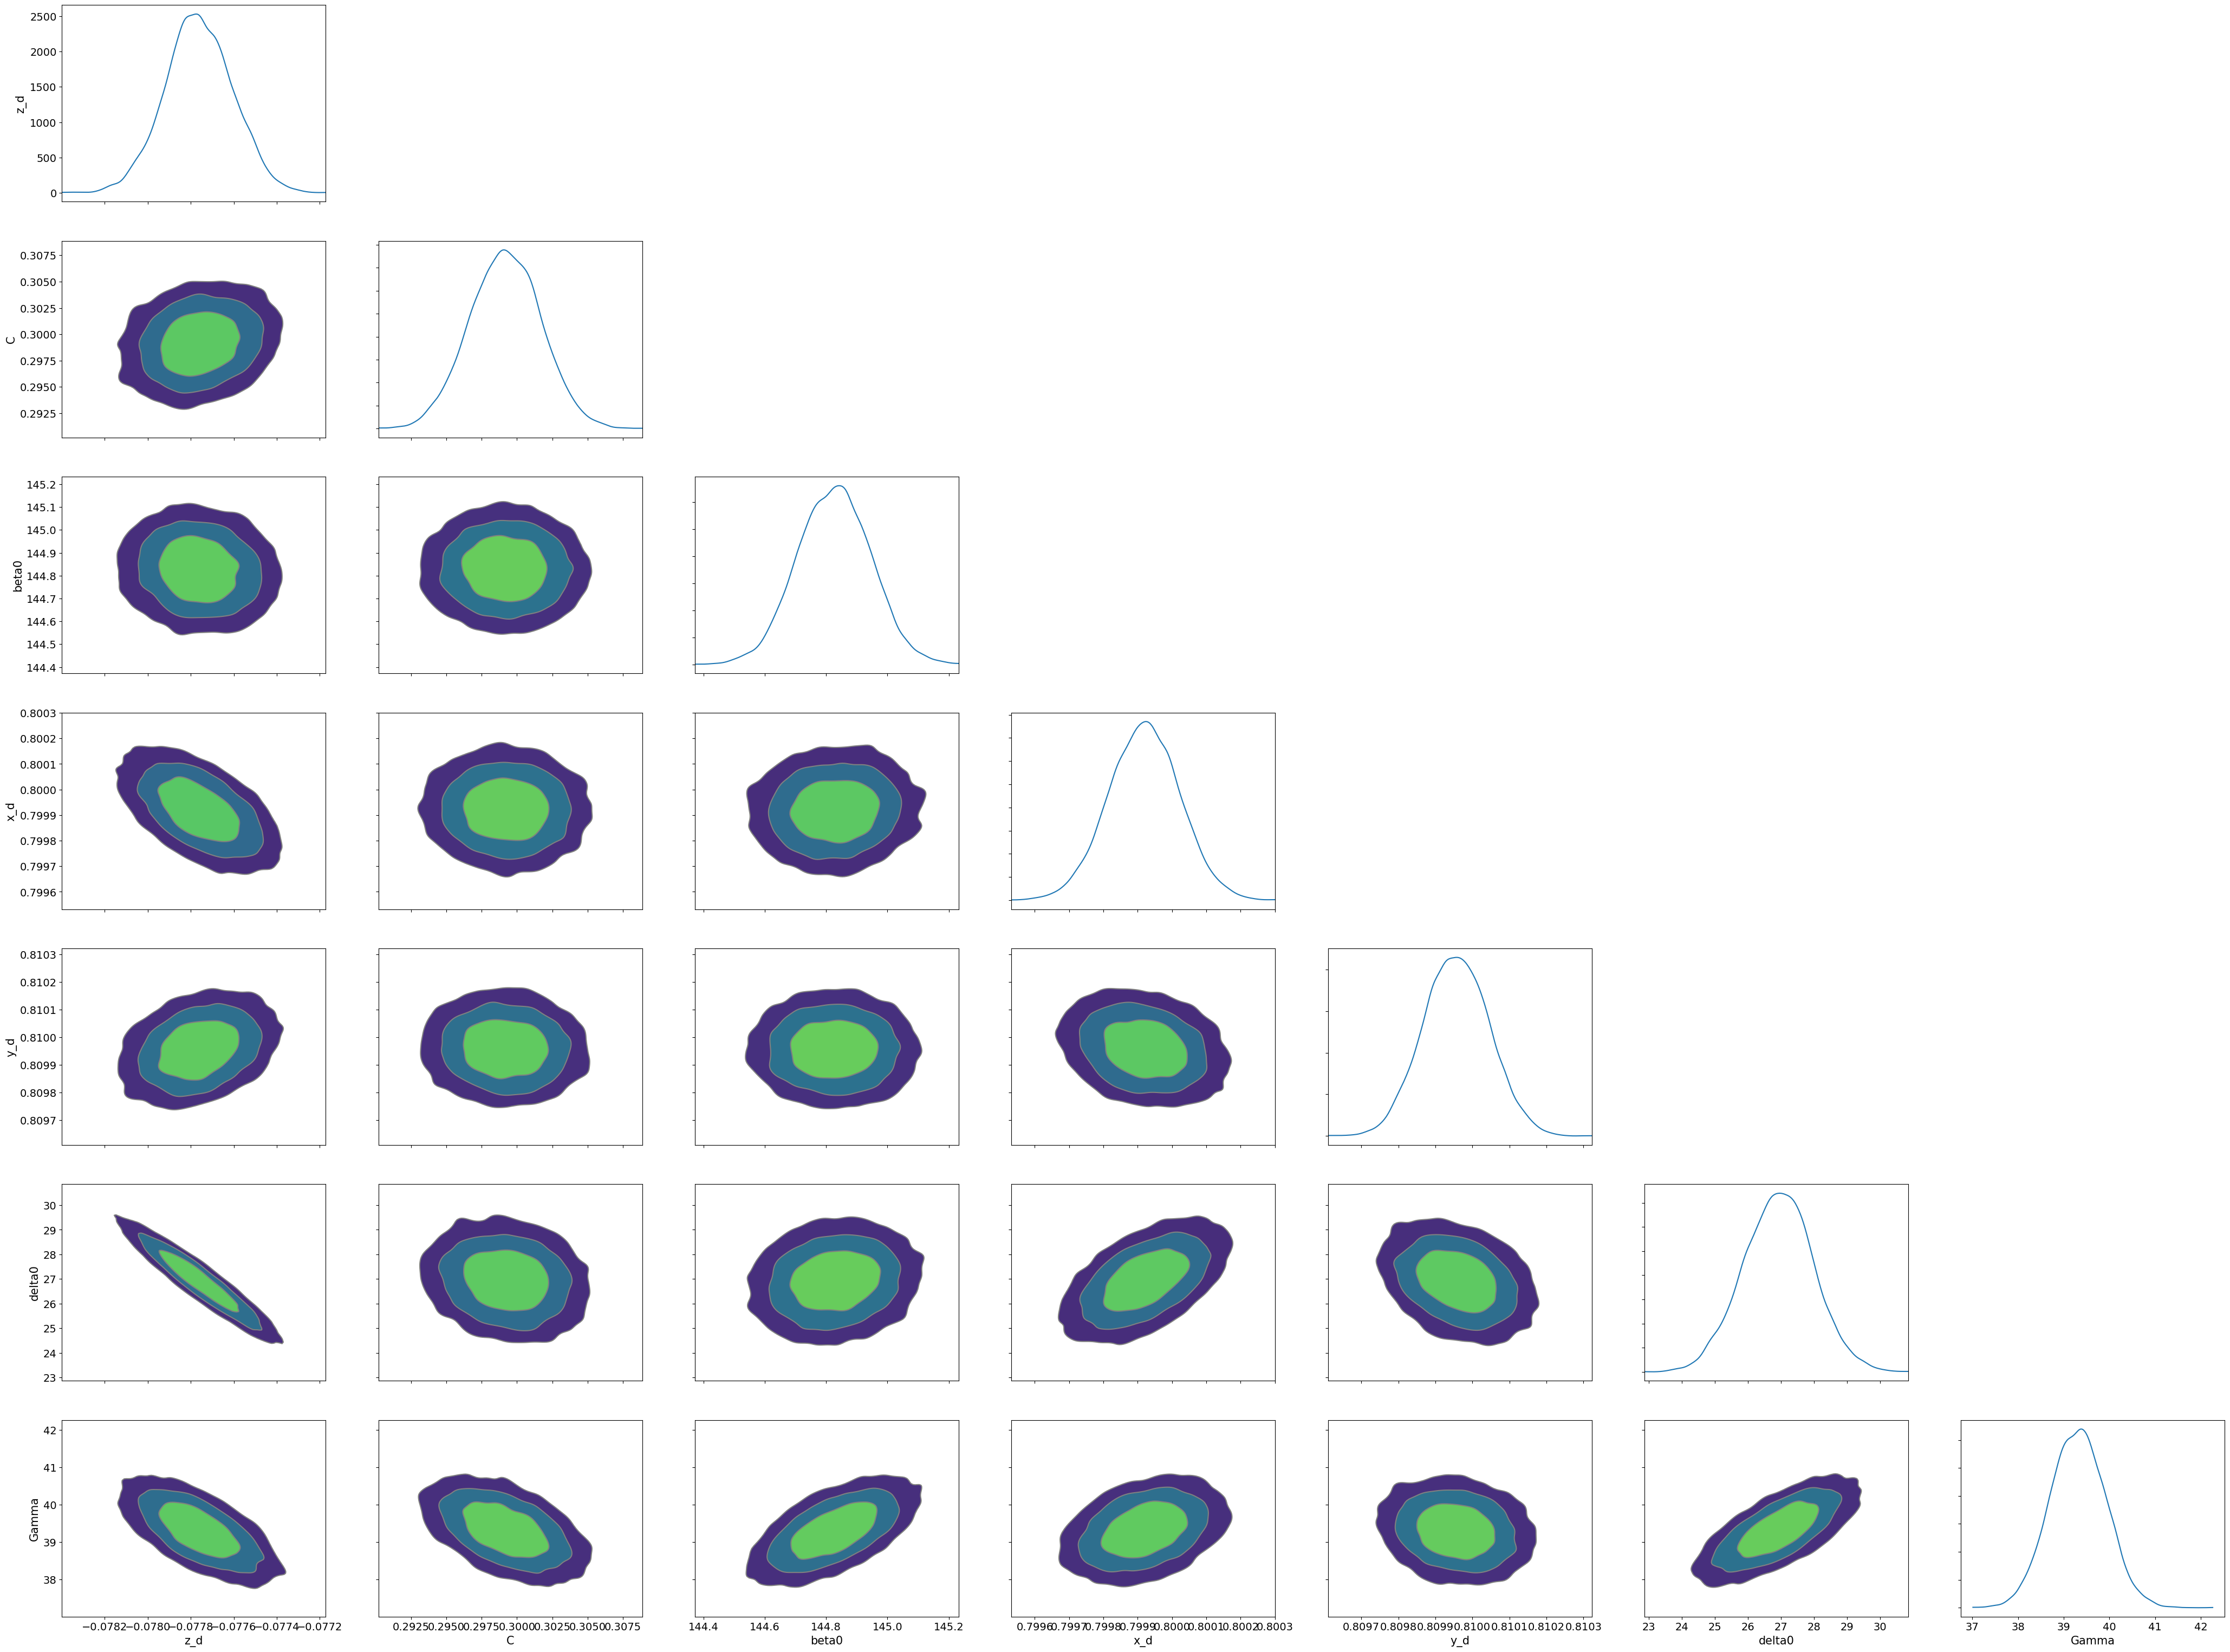

In [18]:
az.plot_pair(
    nv_samples,
    var_names=["z_d", "C", "beta0", "x_d", "y_d", "delta0", "Gamma"],
    kind="kde",
    marginals=True
)

We see that z_d and $\delta_0$ are highly coorelated. This makes sense, because $\delta_0$ represetns the offset from the resonant condition. So, the ring in the image is the place where $\delta_0 = B_\parallel$, i.e. it is the level set of the dipole field. So, if $z_d$ increases, then the field weakens, then the model can reduce $\delta_0$ so that the resonance condition happens at a similar contour. But in our case, maybe this is something that will be fixes based on given knowledge. 

**NOTE:** Letting the dipole vector be a free parameter really breaks the HMC simulation. I think this is becuase the system becomes extremely unconstrained, eg small tilts in the dipole could compeltely change the x or y interpretation, the delta intepretation, it probably creates a landscape which is super unfriendly to HMC. 

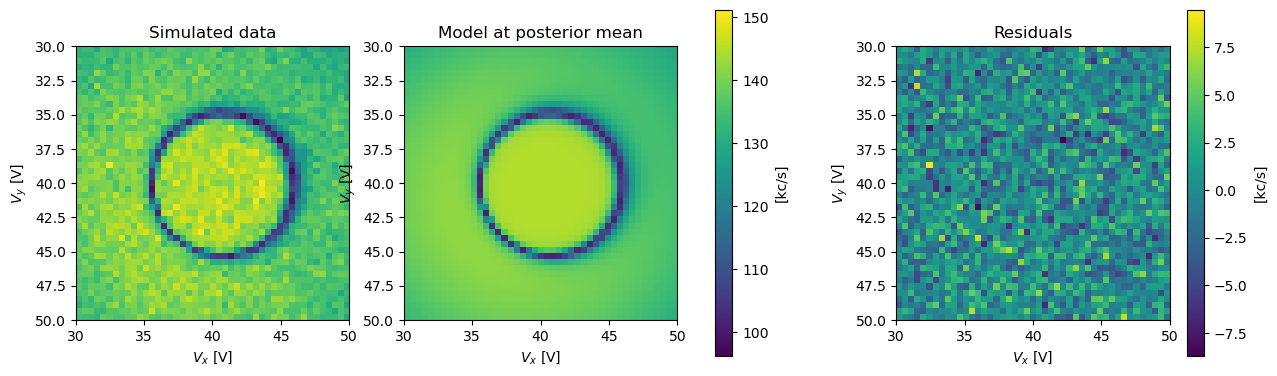

In [23]:
summary = az.summary(nv_samples, var_names=["x_d", "y_d", "z_d", "C", "beta0", "delta0", "Gamma"])

x_mean = summary.loc["x_d", "mean"]
y_mean = summary.loc["y_d", "mean"]
z_mean = summary.loc["z_d", "mean"]
C_mean = summary.loc["C", "mean"]
beta0_mean = summary.loc["beta0", "mean"]
delta0_mean = summary.loc["delta0", "mean"]
Gamma_mean = summary.loc["Gamma", "mean"]

mu_fit, _, _ = mean_fluorescence(
    X, Y, Z,
    x_mean, y_mean, z_mean,
    m_vec_true,
    n_vec_true,
    beta0_mean,
    C_mean,
    Gamma_mean,
    delta0_mean
)

# Residuals
residual = y_sim - mu_fit

# Match color scales for viewing purppose
vmin = min(y_sim.min(), mu_fit.min())
vmax = max(y_sim.max(), mu_fit.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

im0 = axes[0].imshow(
    y_sim,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
    vmin=vmin, vmax=vmax
)
axes[0].set_title("Simulated data")
axes[0].set_xlabel("$V_x$ [V]")
axes[0].set_ylabel("$V_y$ [V]")

im1 = axes[1].imshow(
    mu_fit,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
    vmin=vmin, vmax=vmax
)
axes[1].set_title("Model at posterior mean")
axes[1].set_xlabel("$V_x$ [V]")
axes[1].set_ylabel("$V_y$ [V]")

im2 = axes[2].imshow(
    residual,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
)
axes[2].set_title("Residuals")
axes[2].set_xlabel("$V_x$ [V]")
axes[2].set_ylabel("$V_y$ [V]")

plt.colorbar(im0, ax=axes[:2], label="[kc/s]")
plt.colorbar(im2, ax=axes[2], label="[kc/s]")

plt.show()

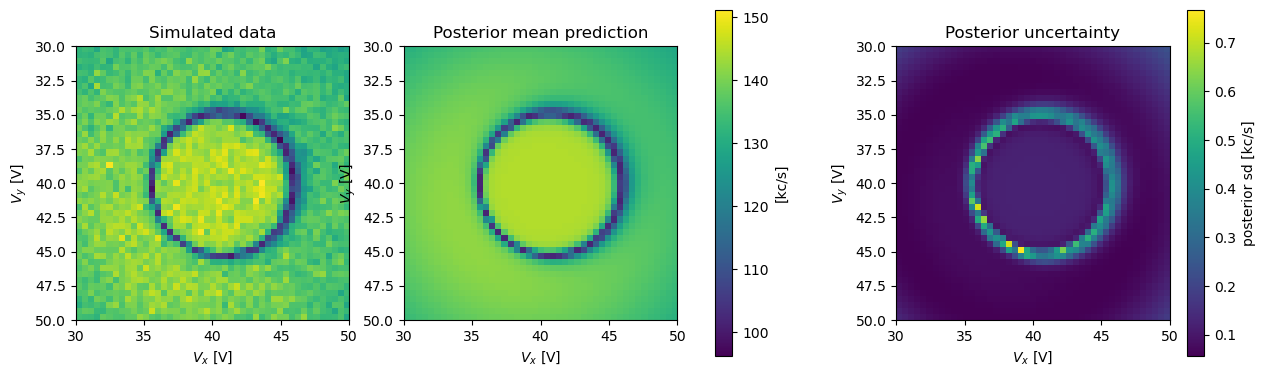

In [24]:
posterior = nv_samples.posterior

x_samps = posterior["x_d"].stack(sample=("chain", "draw")).values
y_samps = posterior["y_d"].stack(sample=("chain", "draw")).values
z_samps = posterior["z_d"].stack(sample=("chain", "draw")).values
C_samps = posterior["C"].stack(sample=("chain", "draw")).values
beta0_samps = posterior["beta0"].stack(sample=("chain", "draw")).values
delta0_samps = posterior["delta0"].stack(sample=("chain", "draw")).values
Gamma_samps = posterior["Gamma"].stack(sample=("chain", "draw")).values

# only use a random subset here of our posteriors
rng = np.random.default_rng(0)
n_keep = min(300, len(x_samps))
idx = rng.choice(len(x_samps), size=n_keep, replace=False)

# now we want to compute an image for each draw
mu_samples = []
for k in idx:
    mu_k, _, _ = mean_fluorescence(
        X, Y, Z,
        x_samps[k], y_samps[k], z_samps[k],
        m_vec_true,
        n_vec_true,
        beta0_samps[k],
        C_samps[k],
        Gamma_samps[k],
        delta0_samps[k]
    )
    mu_samples.append(mu_k)

mu_samples = np.array(mu_samples)

# With many samples, we can take mean AND St Dev
mu_post_mean = mu_samples.mean(axis=0)
mu_post_std = mu_samples.std(axis=0)

# Finally plot
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# scale color bars
vmin = min(y_sim.min(), mu_post_mean.min())
vmax = max(y_sim.max(), mu_post_mean.max())

im0 = axes[0].imshow(
    y_sim,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
    vmin=vmin, vmax=vmax
)
axes[0].set_title("Simulated data")
axes[0].set_xlabel("$V_x$ [V]")
axes[0].set_ylabel("$V_y$ [V]")

im1 = axes[1].imshow(
    mu_post_mean,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
    vmin=vmin, vmax=vmax
)
axes[1].set_title("Posterior mean prediction")
axes[1].set_xlabel("$V_x$ [V]")
axes[1].set_ylabel("$V_y$ [V]")

im2 = axes[2].imshow(
    mu_post_std,
    extent=[vx.min(), vx.max(), vy.max(), vy.min()],
)
axes[2].set_title("Posterior uncertainty")
axes[2].set_xlabel("$V_x$ [V]")
axes[2].set_ylabel("$V_y$ [V]")

plt.colorbar(im0, ax=axes[:2], label="[kc/s]")
plt.colorbar(im2, ax=axes[2], label="posterior sd [kc/s]")

plt.show()